**`Step 1: Import Libraries`**

In [ ]:
# Data handling libraries
import pandas as pd              # Used to load and manipulate tabular data
import numpy as np               # Used for numerical operations

# Visualization libraries
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For advanced visualization

# Machine learning preprocessing tools
from sklearn.model_selection import train_test_split  # Split dataset into train/test
from sklearn.preprocessing import StandardScaler      # Scale numerical features
from sklearn.preprocessing import OneHotEncoder       # Encode categorical data
from sklearn.compose import ColumnTransformer         # Apply different preprocessing per column
from sklearn.pipeline import Pipeline                 # Create preprocessing pipeline
from sklearn.impute import SimpleImputer              # Handle missing values

**Step 2: Load Dataset**


* read_csv() → loads dataset into memory
* head() → shows structure and sample values



In [ ]:
# Load dataset from CSV file
data = pd.read_csv('/content/Heart_Disease_Prediction.csv')

# Display first 5 rows
data.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


**Step 3: Understand Dataset**


*   info() → data types + missing values
*   describe() → mean, std, min, max
*   isnull().sum() → identifies missing data





In [ ]:
# Check dataset information
data.info()

# Statistical summary
data.describe()

# Check missing values
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    int64  
dtypes: float64(1), int64(13)
m

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**Step 4: Rename Columns (IMPORTANT for clean coding)**
Your dataset contains spaces in column names → this can cause issues.


*   Makes column names easier to use in code
*   Example: Chest pain type → Chest_pain_type



In [ ]:
# Replace spaces with underscore for easier access
data.columns = data.columns.str.replace(' ', '_')

# Check updated column names
data.columns

Index(['Age', 'Sex', 'Chest_pain_type', 'BP', 'Cholesterol', 'FBS_over_120',
       'EKG_results', 'Max_HR', 'Exercise_angina', 'ST_depression',
       'Slope_of_ST', 'Number_of_vessels_fluro', 'Thallium', 'Heart_Disease'],
      dtype='object')

**Step 5: Separate Features and Target**


*   X → all input variables
*   y → prediction target (0 or 1)



In [ ]:
# Define input features (X)
X = data.drop('Heart_Disease', axis=1)

# Define target variable (y)
y = data['Heart_Disease']

**Step 6: Train-Test Split (CRITICAL STEP)**
*   Prevents data leakage
*   Model learns only from training data

In [ ]:
# Split dataset into training and testing sets

from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


**Step 7: Identify Feature Types**


*   Different preprocessing for different data types
*   In your dataset → most features are numerical



In [ ]:
# Select numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Select categorical columns (if any)
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['Age', 'Sex', 'Chest_pain_type', 'BP', 'Cholesterol', 'FBS_over_120',
       'EKG_results', 'Max_HR', 'Exercise_angina', 'ST_depression',
       'Slope_of_ST', 'Number_of_vessels_fluro', 'Thallium'],
      dtype='object')
Categorical Columns: Index([], dtype='object')


**Step 8: Create Preprocessing Pipelines**
**8.1 Numerical Pipeline**

*   median → robust for real-world data
*   StandardScaler → ensures equal feature importance



In [ ]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing values
    ('scaler', StandardScaler())                   # Normalize data
])

**8.2 Categorical Pipeline (if exists)**

In [ ]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # Convert text to numeric
])

**Step 9: Combine Pipelines**
Applies:
*  Scaling → numerical features
*  Encoding → categorical features





In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

**Step 10: Apply Preprocessing**
*  fit_transform() → learns + applies
*  transform() → applies only
*  Prevents data leakage







In [ ]:
# Fit on training data and transform
X_train_processed = preprocessor.fit_transform(X_train)

# Only transform test data (IMPORTANT)
X_test_processed = preprocessor.transform(X_test)

**Step 11: Feature Engineering**
Now we create new meaningful features.
| Feature        | Meaning                                   |
| -------------- | ----------------------------------------- |
| chol_age_ratio | Higher value → higher cardiovascular risk |
| bp_stress      | Measures stress on heart                  |
| high_risk      | Binary classification feature             |


In [ ]:
# Create a copy of dataset
X_fe = X.copy()

# Feature 1: Cholesterol to Age Ratio
X_fe['chol_age_ratio'] = X_fe['Cholesterol'] / X_fe['Age']

# Feature 2: Heart Stress Index (Corrected column names)
X_fe['bp_stress'] = X_fe['Max_HR'] - X_fe['BP']

# Feature 3: High Risk Flag
X_fe['high_risk'] = (X_fe['ST_depression'] > 2).astype(int)

# Show first rows
X_fe.head()

,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,chol_age_ratio,bp_stress,high_risk
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,4.600000,-21,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,8.417910,45,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,4.578947,17,0
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,4.109375,-23,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,3.635135,1,0


**Step 12: Visualization (Understanding Data)**
Helps identify:
*   Skewness
*   Outliers
*   Distribution shape






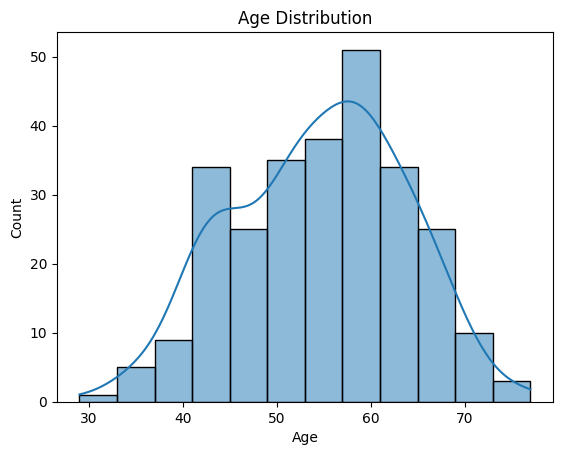

In [ ]:
# Plot Age distribution
sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

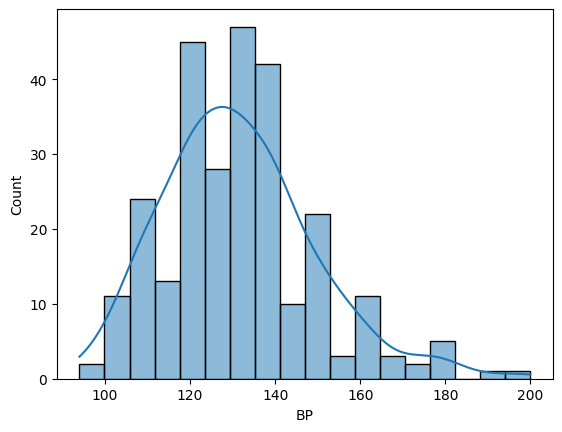

In [ ]:
sns.histplot(data['BP'], kde=True)
plt.show()

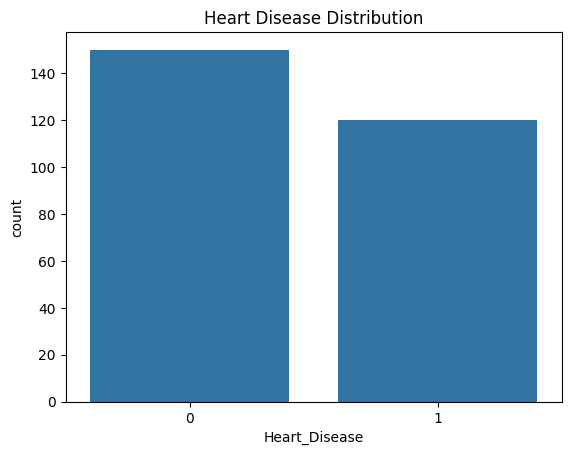

In [ ]:
sns.countplot(x="Heart_Disease", data=data)
plt.title("Heart Disease Distribution")
plt.show()

**Step 13: Check Correlation**

*   Shows relationships between variables
*   Helps in feature selection

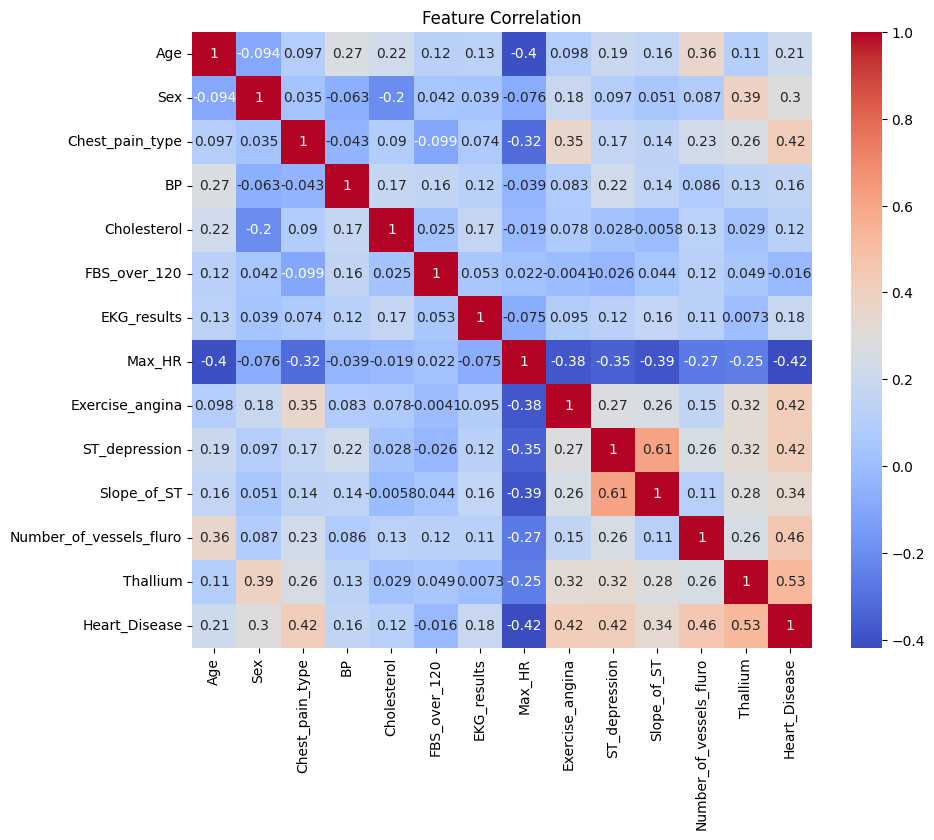

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

**Supervised Learning: Regression & Classification**

**Step 1: Import Libraries for Supervised Learning Models**

These are common supervised learning algorithms
*  Classification → predicts categories
*  Regression → predicts continuous values






In [ ]:
# Import classification algorithms
from sklearn.linear_model import LogisticRegression        # Linear classification
from sklearn.tree import DecisionTreeClassifier            # Tree-based model
from sklearn.ensemble import RandomForestClassifier        # Ensemble model
from sklearn.svm import SVC                                # Support Vector Machine
from sklearn.naive_bayes import GaussianNB                 # Probabilistic model
from sklearn.ensemble import GradientBoostingClassifier    # Boosting model

# Import regression models (for concept demonstration)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Import pipeline
from sklearn.pipeline import Pipeline

**Step 2: Logistic Regression Model**

*  LogisticRegression() → classification algorithm
*  fit() → learns patterns from processed data
* predict() → predicts new data



In [ ]:
# Create pipeline for Logistic Regression
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),               # Apply preprocessing
    ('model', LogisticRegression(max_iter=1000))  # Logistic regression model
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

**Step 3: Decision Tree Model**

*  max_depth=5 → limits tree size to avoid overfitting
*  Learns decision rules from data



In [ ]:
# Create pipeline for Decision Tree
tree_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=5, random_state=42))
])

# Train model
tree_model.fit(X_train, y_train)

# Predict
y_pred_tree = tree_model.predict(X_test)

**Step 4: Random Forest Model**

*  n_estimators=100 → number of trees
*  Combines multiple trees → more robust



In [ ]:
# Create pipeline for Random Forest
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

**Step 5: Support Vector Machine (SVM)**
*  kernel='rbf' → handles complex patterns
*  Separates data using optimal boundary



In [ ]:
# Create pipeline for SVM
svm_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', SVC(kernel='rbf'))
])

# Train model
svm_model.fit(X_train, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test)

**Step 6: Naïve Bayes Model**
*  Based on probability
*  Assumes features are independent



In [ ]:
# Create pipeline for Naive Bayes
nb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GaussianNB())
])

# Train model
nb_model.fit(X_train, y_train)

# Predict
y_pred_nb = nb_model.predict(X_test)

**Step 7: Gradient Boosting Model**
*  Learns sequentially
*  Each step improves previous errors


In [ ]:
# Create pipeline for Gradient Boosting
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier())
])

# Train model
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

**Model Evaluation: Metrics, Confusion Matrix, and ROC Curve**

**Step 1: Import Evaluation Libraries**


*  accuracy_score → percentage of correct predictions
*  confusion_matrix → shows types of errors (TP, TN, FP, FN)
*  classification_report → detailed metrics
*  roc_curve → evaluates performance across thresholds
*  auc → summarizes ROC performance
*  matplotlib, seaborn → visualization










In [ ]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score      # Measures overall correctness
from sklearn.metrics import confusion_matrix    # Shows prediction errors
from sklearn.metrics import classification_report  # Precision, Recall, F1-score
from sklearn.metrics import precision_score, recall_score, f1_score  # Individual metrics
from sklearn.metrics import roc_curve, auc      # ROC and AUC

# Import visualization tools
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Evaluate Accuracy for All Models**
*  for model_name, y_pred in predictions.items()→ iterates over each trained model
*  accuracy_score(y_test, y_pred)→ compares actual vs predicted values
*  :.4f→ formats result to 4 decimal places

In [ ]:
# Create predictions dictionary safely
predictions = {}

# Add models one by one (only if they exist)

try:
    predictions["Logistic Regression"] = y_pred_logistic
except:
    print("Logistic model not found")

try:
    predictions["Decision Tree"] = y_pred_tree
except:
    print("Decision Tree not found")

try:
    predictions["Random Forest"] = y_pred_rf
except:
    print("Random Forest not found")

try:
    predictions["SVM"] = y_pred_svm
except:
    print("SVM not found")

try:
    predictions["Naive Bayes"] = y_pred_nb
except:
    print("Naive Bayes not found")

try:
    predictions["Gradient Boosting"] = y_pred_gb
except:
    print("Gradient Boosting not found")

**Step 3: Evaluate Accuracy for All Models**

We calculate the accuracy for all models.

In [ ]:
# Loop through all trained models and calculate accuracy
for model_name, y_pred in predictions.items():

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Print result
    print(f"{model_name} Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.9074
Decision Tree Accuracy: 0.7037
Random Forest Accuracy: 0.7593
SVM Accuracy: 0.8889
Naive Bayes Accuracy: 0.9074
Gradient Boosting Accuracy: 0.7593


**Step 4: Confusion Matrix**

A confusion matrix shows:
*   correct predictions
*   incorrect predictions
*   false positives
*   false negatives

In [ ]:
# Select a model (example: Logistic Regression)
y_pred = predictions["Logistic Regression"]

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display matrix
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[31  2]
 [ 3 18]]


**Step 5: Visualize Confusion Matrices for All Models**

We visualize the confusion matrix for all models.
*   sns.heatmap() → visual grid
*  annot=True → shows numbers inside cells
*  fmt='d' → integer format


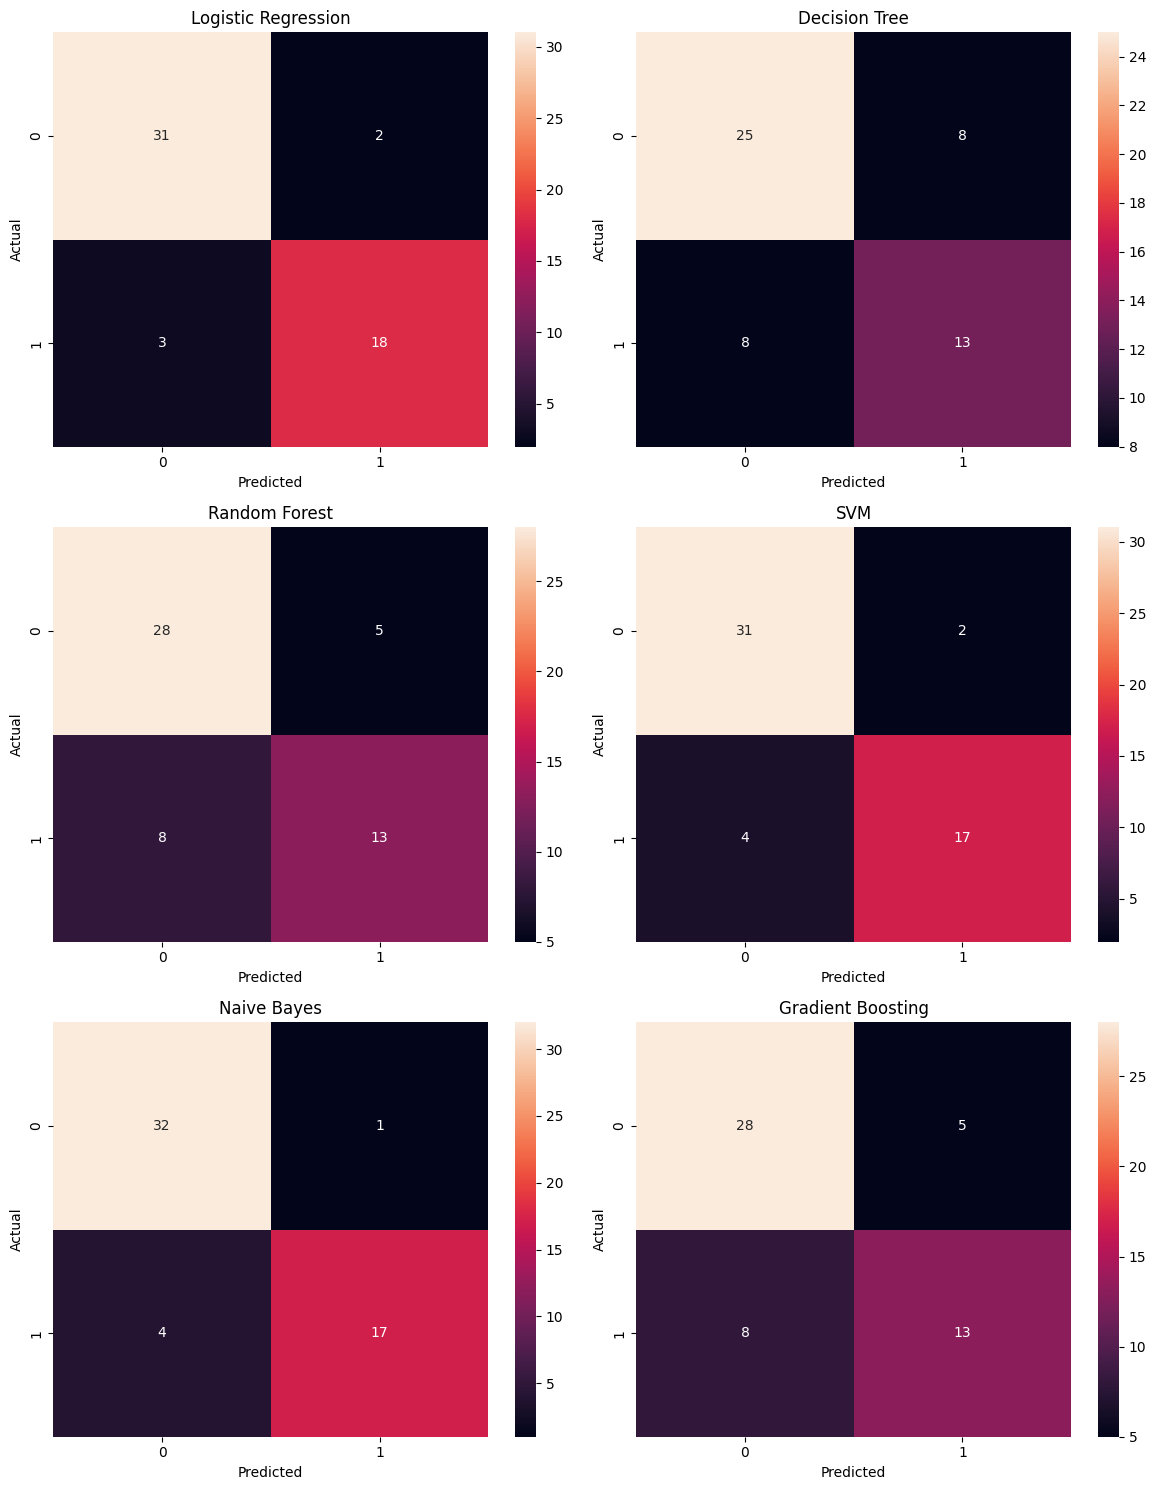

In [ ]:
# Import required library
import math

# Number of models
num_models = len(predictions)

# Define grid size (2 columns for left-right layout)
cols = 2
rows = math.ceil(num_models / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Loop through models
for i, (model_name, y_pred) in enumerate(predictions.items()):

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap in subplot
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i])

    # Set title and labels
    axes[i].set_title(f"{model_name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

# Remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

**Step 6: Classification Report for All Models**
*   We generate the classification report.
*   This provides detailed evaluation metrics.

In [ ]:
# Print classification report for each model
# Loop through all models and print classification report
for model_name, y_pred in predictions.items():

    # Print model title
    print("=" * 50)
    print(f"Model: {model_name}")
    print("=" * 50)

    # Generate classification report
    report = classification_report(y_test, y_pred)

    # Print report
    print(report)

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

Model: Decision Tree
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        33
           1       0.62      0.62      0.62        21

    accuracy                           0.70        54
   macro avg       0.69      0.69      0.69        54
weighted avg       0.70      0.70      0.70        54

Model: Random Forest
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        33
           1       0.72      0.62      0.67        21

    accuracy                           0.76        54
   macro avg       0.75      0.73      0.74        54
weigh

**Step 7: Compare All Models in One Table**

we create a summary table.

In [ ]:
# Create empty list to store results
report_list = []

# Loop through all models
for model_name, y_pred in predictions.items():

    # Convert classification report to dictionary
    report = classification_report(y_test, y_pred, output_dict=True)

    # Extract metrics for positive class (class '1')
    report_list.append({
        "Model": model_name,
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "Accuracy": report["accuracy"]
    })

# Convert to DataFrame
df_report = pd.DataFrame(report_list)

# Display table
df_report

,Model,Precision,Recall,F1-Score,Accuracy
0,Logistic Regression,0.900000,0.857143,0.878049,0.907407
1,Decision Tree,0.619048,0.619048,0.619048,0.703704
2,Random Forest,0.722222,0.619048,0.666667,0.759259
3,SVM,0.894737,0.809524,0.850000,0.888889
4,Naive Bayes,0.944444,0.809524,0.871795,0.907407
5,Gradient Boosting,0.722222,0.619048,0.666667,0.759259


*  Stores results in dictionary
*  Enables comparison across models

In [ ]:
# Store accuracy results
results = {}

# Loop through predictions
for model_name, y_pred in predictions.items():

    # Calculate accuracy
    results[model_name] = accuracy_score(y_test, y_pred)

# Print comparison
for model, score in results.items():
    print(f"{model}: {score:.4f}")

**Step 8: ROC Curve and AUC**
*   We evaluate model performance using ROC Curve and AUC.
*   ROC curves help measure how well the model separates classes.

In [ ]:
# Store trained models (MUST match your training variables)
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model,
    "Gradient Boosting": gb_model
}




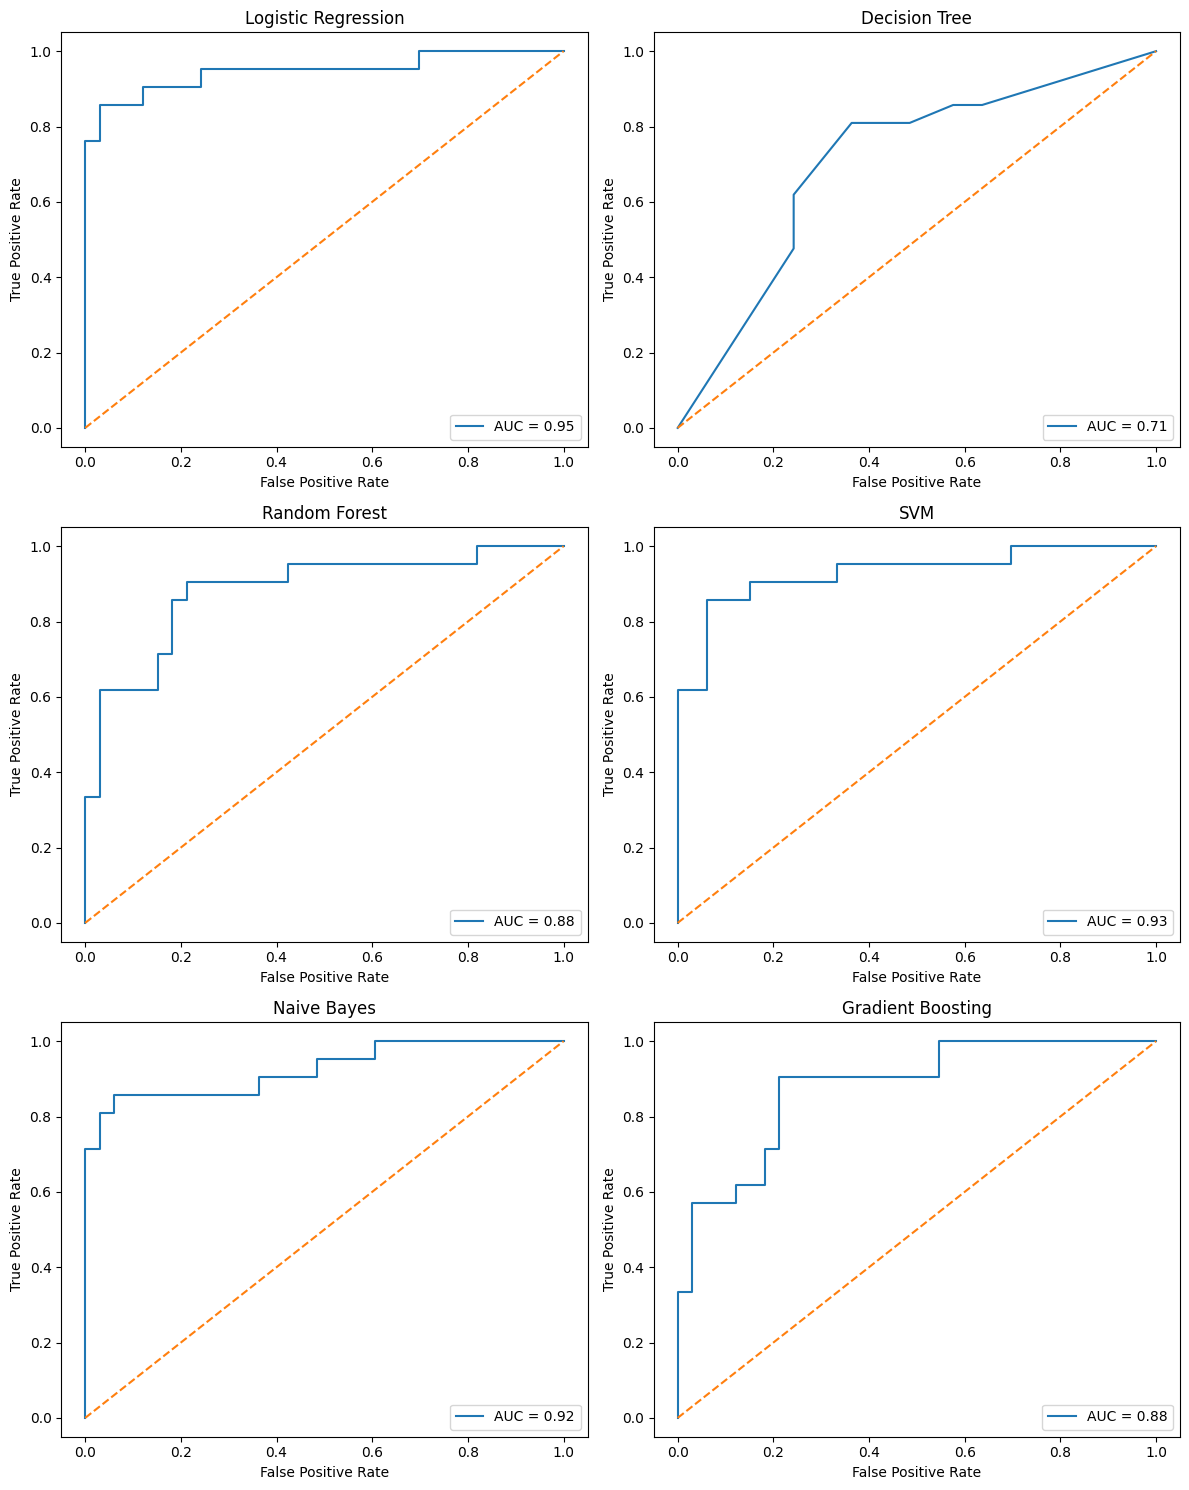

In [ ]:
# Import required libraries
import matplotlib.pyplot as plt
import math

from sklearn.metrics import roc_curve, auc

# Store trained models
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Naive Bayes": nb_model,
    "Gradient Boosting": gb_model
}

# Number of models
num_models = len(models)

# Define grid layout
cols = 2
rows = math.ceil(num_models / cols)

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))

# Flatten axes
axes = axes.flatten()

# Loop through each model
for i, (model_name, model) in enumerate(models.items()):

    try:
        # If model supports probability prediction
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]

        # If model supports decision function, like SVM
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)

        else:
            axes[i].set_title(f"{model_name}\nROC not available")
            axes[i].axis("off")
            continue

        # Calculate ROC values
        fpr, tpr, thresholds = roc_curve(y_test, y_score)

        # Calculate AUC score
        roc_auc = auc(fpr, tpr)

        # Plot ROC curve
        axes[i].plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

        # Plot baseline line
        axes[i].plot([0, 1], [0, 1], linestyle="--")

        # Add labels and title
        axes[i].set_title(model_name)
        axes[i].set_xlabel("False Positive Rate")
        axes[i].set_ylabel("True Positive Rate")
        axes[i].legend(loc="lower right")

    except Exception as e:
        axes[i].set_title(f"{model_name}\nError: {str(e)}")
        axes[i].axis("off")

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()